In [1]:
import pandas as pd
import requests
import json
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rcParams["figure.figsize"] = (10, 7)
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.interpolate import interp1d
from tqdm.notebook import tqdm
from statsmodels.tsa.seasonal import STL
import requests
import json
import numpy as np
import re
import plotly.express as ex
from airrship.create_repertoire import (
    generate_sequence,
    load_data,
    get_genotype,
    create_allele_dict,
)
import importlib
import plotly.io as pio

tqdm.pandas()
# from Bio.Align.Applications import ClustalOmegaCommandline
# from Bio import AlignIO, SeqIO
# from Bio.SeqRecord import SeqRecord
# from Bio.Seq import Seq
import os
from scipy.stats import entropy
import matplotlib as mpl
from collections import defaultdict
import numpy as np
from VDeepJModelExperimental import (
    VDeepJAllignExperimentalSingleBeamConvSegmentationResidualRF,
)
from Trainer import SingleBeamSegmentationTrainer
import tensorflow as tf

physical_devices = tf.config.experimental.list_physical_devices("GPU")
config = tf.config.experimental.set_memory_growth(physical_devices[0], True)

<frozen importlib._bootstrap>:219: RuntimeWarning: scipy._lib.messagestream.MessageStream size changed, may indicate binary incompatibility. Expected 56 from C header, got 64 from PyObject
2023-11-01 08:14:04.240208: I tensorflow/stream_executor/platform/default/dso_loader.cc:49] Successfully opened dynamic library libcudart.so.10.1
2023-11-01 08:14:11.980055: I tensorflow/compiler/jit/xla_cpu_device.cc:41] Not creating XLA devices, tf_xla_enable_xla_devices not set
2023-11-01 08:14:11.983227: I tensorflow/stream_executor/platform/default/dso_loader.cc:49] Successfully opened dynamic library libcuda.so.1
2023-11-01 08:14:12.010941: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1720] Found device 0 with properties: 
pciBusID: 0000:65:00.0 name: TITAN RTX computeCapability: 7.5
coreClock: 1.77GHz coreCount: 72 deviceMemorySize: 23.65GiB deviceMemoryBandwidth: 625.94GiB/s
2023-11-01 08:14:12.011039: I tensorflow/stream_executor/platform/default/dso_loader.cc:49] Successfully opened d

In [2]:
mpl.rcParams["figure.figsize"] = (20, 11)
sns.set_context("poster")
tokenizer_dictionary = {
    "A": 1,
    "T": 2,
    "G": 3,
    "C": 4,
    "N": 5,
    "P": 0,  # pad token
}
import pickle


def _process_and_dpad(sequence, train=True):
    start, end = None, None
    trans_seq = [tokenizer_dictionary[i] for i in sequence]

    gap = max_length - len(trans_seq)
    iseven = gap % 2 == 0
    whole_half_gap = gap // 2

    if iseven:
        trans_seq = [0] * whole_half_gap + trans_seq + ([0] * whole_half_gap)
        if train:
            start, end = whole_half_gap, max_length - whole_half_gap - 1

    else:
        trans_seq = [0] * (whole_half_gap + 1) + trans_seq + ([0] * whole_half_gap)
        if train:
            start, end = (whole_half_gap + 1, max_length - whole_half_gap - 1)

    return trans_seq, start, end if iseven else (end + 1)


def process_sequences(self, data: pd.DataFrame, corrupt_beginning=False, verbose=False):
    padded_sequences = []
    v_start, v_end, d_start, d_end, j_start, j_end = [], [], [], [], [], []
    iterator = (
        tqdm(data.itertuples(), total=len(data)) if verbose else data.itertuples()
    )
    for row in iterator:
        seq = row.sequence
        padded_array, start, end = _process_and_dpad(seq, self.max_length)
        padded_sequences.append(padded_array)
        _adjust = start

        v_start.append(start)
        j_end.append(end)
        v_end.append(row.v_sequence_end + _adjust)
        d_start.append(row.d_sequence_start + _adjust)
        d_end.append(row.d_sequence_end + _adjust)
        j_start.append(row.j_sequence_start + _adjust)

    v_start = np.array(v_start)
    v_end = np.array(v_end)
    d_start = np.array(d_start)
    d_end = np.array(d_end)
    j_start = np.array(j_start)
    j_end = np.array(j_end)

    padded_sequences = np.vstack(padded_sequences)

    return v_start, v_end, d_start, d_end, j_start, j_end, padded_sequences


def global_genotype():
    try:
        path_to_data = importlib.resources.files("airrship").joinpath("data")
    except AttributeError:
        with importlib.resources.path("airrship", "data") as p:
            path_to_data = p
    v_alleles = create_allele_dict(f"{path_to_data}/imgt_human_IGHV.fasta")
    d_alleles = create_allele_dict(f"{path_to_data}/imgt_human_IGHD.fasta")
    j_alleles = create_allele_dict(f"{path_to_data}/imgt_human_IGHJ.fasta")

    vdj_allele_dicts = {"V": v_alleles, "D": d_alleles, "J": j_alleles}

    chromosome1, chromosome2 = defaultdict(list), defaultdict(list)
    for segment in ["V", "D", "J"]:
        allele_dict = vdj_allele_dicts[segment]
        for gene in allele_dict.values():
            for allele in gene:
                chromosome1[segment].append(allele)
                chromosome2[segment].append(allele)

    locus = [chromosome1, chromosome2]
    return locus


def decompose_call(call):
    family, G = call.split("-", 1)
    gene, allele = G.split("*")
    return family, gene, allele


locus = global_genotype()

from VDeepJUnbondedDataset import global_genotype

locus = global_genotype()
v_dict = {i.name: i.ungapped_seq.upper() for i in locus[0]["V"]}
d_dict = {i.name: i.ungapped_seq.upper() for i in locus[0]["D"]}
j_dict = {i.name: i.ungapped_seq.upper() for i in locus[0]["J"]}

v_alleles = sorted(list(v_dict))
d_alleles = sorted(list(d_dict))
j_alleles = sorted(list(j_dict))

v_allele_count = len(v_alleles)
d_allele_count = len(d_alleles)
j_allele_count = len(j_alleles)


v_allele_call_ohe = {f: i for i, f in enumerate(v_alleles)}
d_allele_call_ohe = {f: i for i, f in enumerate(d_alleles)}
j_allele_call_ohe = {f: i for i, f in enumerate(j_alleles)}

v_allele_call_rev_ohe = {i: f for i, f in enumerate(v_alleles)}
d_allele_call_rev_ohe = {i: f for i, f in enumerate(d_alleles)}
j_allele_call_rev_ohe = {i: f for i, f in enumerate(j_alleles)}


def encode_igb_v_call(v_call):
    v = np.zeros(len(v_allele_call_rev_ohe))
    for i in v_call.split(","):
        v[v_allele_call_ohe[i]] = 1
    return v

In [3]:
# for data generation
from airrship.create_repertoire import (
    generate_sequence,
    load_data,
    get_genotype,
    create_allele_dict,
)

data_dict = load_data()


def predict_sample(sample):
    eval_dataset_ = trainer.train_dataset.tokenize_sequences([sample])
    padded_seqs_tensor = tf.convert_to_tensor(eval_dataset_, dtype=tf.int32)
    dataset_from_tensors = tf.data.Dataset.from_tensor_slices(
        {
            "tokenized_sequence": padded_seqs_tensor,
            "tokenized_sequence_for_masking": padded_seqs_tensor,
        }
    )
    dataset = dataset_from_tensors.batch(1).prefetch(tf.data.AUTOTUNE)

    predicted = trainer.model.predict(dataset, verbose=True)
    return predicted


def get_v_latent_projection(sequence):
    eval_dataset_ = trainer.train_dataset.tokenize_sequences([sequence])
    v_mask_input_embedding = trainer.model.concatenated_v_mask_input_embedding(
        eval_dataset_
    )
    v_feature_map = trainer.model._encode_masked_v_signal(v_mask_input_embedding)

    v_allele_latent = trainer.model.v_allele_mid(v_feature_map)
    v_allele_latent = dec.transform(v_allele_latent.numpy())
    return v_allele_latent[0]


def getting_padding_size(seq, max_length=512):
    start, end = None, None
    gap = max_length - len(seq)
    iseven = gap % 2 == 0
    whole_half_gap = gap // 2

    if iseven:
        start, end = whole_half_gap, whole_half_gap

    else:
        start, end = whole_half_gap + 1, whole_half_gap
    return start, end


def log_threshold(prediction, th=0.4):
    ast = np.argsort(prediction)[::-1]
    R = [ast[0]]
    for ip in range(1, len(ast)):
        DIFF = np.log(prediction[ast[ip - 1]] / prediction[ast[ip]])
        if DIFF < th:
            R.append(ast[ip])
        else:
            break
    return R


def extract_prediction_alleles(probabilites, th=0.4):
    V_ratio = []
    for v_all in probabilites:
        v_alleles = log_threshold(v_all, th=th)
        V_ratio.append([v_allele_call_rev_ohe[i] for i in v_alleles])
    return V_ratio

In [4]:
def dynamic_cumulative_confidence_threshold(prediction, percentage=0.9):
    sorted_indices = np.argsort(prediction)[::-1]
    selected_labels = []
    cumulative_confidence = 0.0

    total_confidence = sum(prediction)
    threshold = percentage * total_confidence

    for idx in sorted_indices:
        cumulative_confidence += prediction[idx]
        selected_labels.append(idx)

        if cumulative_confidence >= threshold:
            break

    return selected_labels


def extract_prediction_alleles_dynamic_sum(probabilites, percentage=0.9):
    V_ratio = []
    for v_all in tqdm(probabilites):
        v_alleles = dynamic_cumulative_confidence_threshold(
            v_all, percentage=percentage
        )
        V_ratio.append([v_allele_call_rev_ohe[i] for i in v_alleles])
    return V_ratio

In [5]:
igb_predicted = pd.read_table(
    r"/localdata/alignairr_data/naive_repertoires/naive_sequences_clean.tsv"
)
import pickle

with open(
    "/localdata/alignairr_data/sf5_alignairr_segmentation_residual_s_v_d_j_embedding_product/VDeepJAllignExperimentalSingleBeamConvSegmentationResidualRF_P1_P11_Predict_raw.pkl",
    "rb",
) as h:
    v_segment, d_segment, j_segment, v_allele, d_allele, j_allele = pickle.load(h)

In [6]:
igb_predicted

,Unnamed: 0,sequence,v_sequence_start,v_sequence_end,d_sequence_start,d_sequence_end,j_sequence_start,j_sequence_end,v_call,d_call,j_call
0,0,GAGTGCTTTCTGAGAGTCATGGACCTCCTGCACAAGAACATGAAAC...,97,388,400.0,415.0,423,472,IGHVF8-G39*03,IGHD1-26*01,IGHJ5*02
1,2,GCTCCTCTAAAGAAGCCCCTGGGAGCACAGCTCATCACCATGGACT...,97,389,409.0,424.0,426,477,IGHVF5-G26*15,"IGHD3-3*01,IGHD3-3*02",IGHJ6*03
2,4,GCTCTTTGTGGTGGCAGCAGCTACAGGTGTCCAGTCCCAGGTGCAG...,38,332,333.0,351.0,355,412,IGHVF5-G26*15,"IGHD5-18*01,IGHD5-5*01",IGHJ6*03
3,6,GAAAGCATCATCCAACAACCACATCCCTTCTCTACAGAAGCCTCTG...,122,416,417.0,421.0,429,476,IGHVF5-G28*03,"IGHD2-15*01,IGHD2-21*01,IGHD2-21*02",IGHJ3*02
4,8,ACCGAGGATTCACCATGGAACTGGGGCTCCGCTGGGTTTTCCTTGT...,72,367,372.0,380.0,382,429,IGHVF2-G11*06,"IGHD2-15*01,IGHD2-21*01,IGHD2-21*02",IGHJ4*02
...,...,...,...,...,...,...,...,...,...,...,...
2759330,4950907,GGAGCATCACCCAGCAACCACATCTGTCCTCTAGAGAATCCCCTGA...,122,416,434.0,447.0,453,490,IGHVF5-G29*03,IGHD6-19*01,IGHJ4*02
2759331,4950908,GAGATCACCTTGAAGGAGTCTGGTCCTACGCTGGTGAAACCCACAC...,2,298,NaN,NaN,317,358,IGHVF6-G33*03,NaN,IGHJ4*02
2759332,4950911,GGGTGATCAGGACTGAACAGAGAGAACTCACCATGGAGTTTGGGCT...,90,383,386.0,396.0,407,453,IGHVF2-G18*02,IGHD2-8*01,IGHJ3*02
2759333,4950912,GGAGCATCACCCAGCAACCACATCTGTCCTCTAGAGAATCCCCTGA...,121,414,424.0,435.0,445,493,IGHVF5-G29*03,"IGHD2-2*01,IGHD2-2*02,IGHD2-2*03",IGHJ5*02


In [7]:
V = extract_prediction_alleles_dynamic_sum(v_allele, percentage=0.9)
hits = [len(set(i.split(",")) & set(j)) > 0 for i, j in zip(igb_predicted.v_call, V)]
AGGREMENT = sum(hits) / len(hits)

  0%|          | 0/2759335 [00:00<?, ?it/s]

In [8]:
match_df = igb_predicted[np.array(hits)][
    ["sequence", "v_sequence_start", "v_sequence_end", "v_call"]
].copy()
match_df["v_call"] = match_df.v_call.apply(lambda x: x.split(","))
match_df["v_call_ar"] = np.array(V)[np.array(hits)]

/tmp/ipykernel_169669/3496581957.py:5: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  match_df["v_call_ar"] = np.array(V)[np.array(hits)]


In [9]:
mismatch_df = igb_predicted[~np.array(hits)][
    ["sequence", "v_sequence_start", "v_sequence_end", "v_call"]
].copy()
mismatch_df["v_call"] = mismatch_df.v_call.apply(lambda x: x.split(","))
mismatch_df["v_call_ar"] = np.array(V)[~np.array(hits)]

/tmp/ipykernel_169669/2167420625.py:5: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  mismatch_df["v_call_ar"] = np.array(V)[~np.array(hits)]


In [10]:
print(match_df.shape)
print(mismatch_df.shape)

(2737637, 5)
(21698, 5)


In [11]:
v_segment_matches = v_segment[np.array(hits)]
v_segment_matches.shape

(2737637, 512)

In [12]:
v_segment_mismatch = v_segment[~np.array(hits)]
v_segment_mismatch.shape

(21698, 512)

In [13]:
def create_vectors(df):
    # Initialize an empty array to store the vectors
    vectors = np.zeros((df.shape[0], 512), dtype=int)

    # Loop through each row in the dataframe
    for index in range(df.shape[0]):
        row = df.iloc[index, :]
        start = row["v_sequence_start"]
        end = row["v_sequence_end"]

        # Set the values in the vector to 1 between start and end indices
        vectors[index, start : end + 1] = 1

    return vectors

In [14]:
igb_one_hot_vector_mathced = create_vectors(match_df)
igb_one_hot_vector_mismatch = create_vectors(mismatch_df)

In [15]:
match_df["v_call"]

0          [IGHVF8-G39*03]
1          [IGHVF5-G26*15]
2          [IGHVF5-G26*15]
3          [IGHVF5-G28*03]
4          [IGHVF2-G11*06]
                ...       
2759329    [IGHVF2-G17*08]
2759331    [IGHVF6-G33*03]
2759332    [IGHVF2-G18*02]
2759333    [IGHVF5-G29*03]
2759334    [IGHVF5-G29*03]
Name: v_call, Length: 2737637, dtype: object

In [161]:
# specific_v_allel = "IGHVF2-G7*01"
specific_v_allel = "IGHVF1-G4*01"
for i, v_calls in enumerate(match_df["v_call"]):
    if specific_v_allel in v_calls:
        specific_index = i

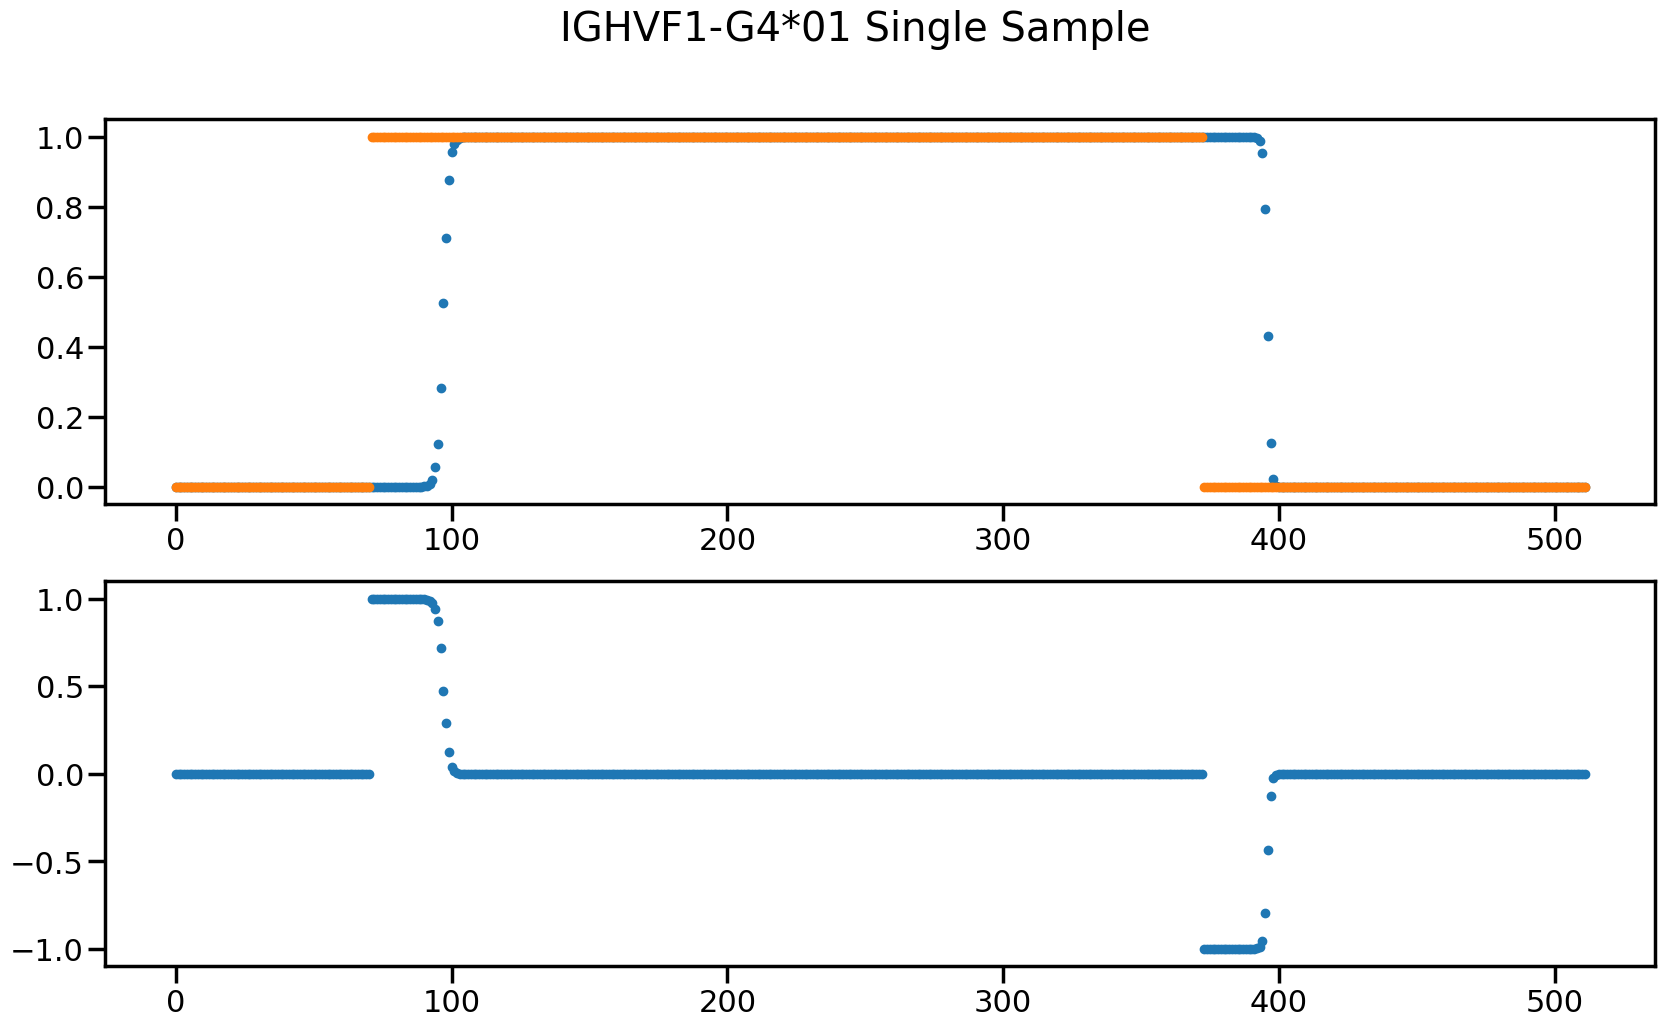

In [162]:
plt.figure()
plt.suptitle(f"{specific_v_allel} Single Sample")
plt.subplot(2, 1, 1)
plt.plot(v_segment_matches[specific_index], '.')
plt.plot(igb_one_hot_vector_mathced[specific_index], '.')
plt.subplot(2, 1, 2)
plt.plot(igb_one_hot_vector_mathced[specific_index] - v_segment_matches[specific_index], '.')

In [29]:
used_v_calls_mismatches = []
# for v_call in pd.unique(match_df["v_call"]):
mismatch_df.reset_index(inplace=True)
for v_calls in mismatch_df["v_call"]:
    for v_call in v_calls:
        if v_call not in used_v_calls_mismatches:
            # v_call_idxs = match_df["v_call"] == v_call
            v_call_idxs = mismatch_df[
                mismatch_df["v_call"].apply(lambda x: v_call in x)
            ].index
            igb_v_call_one_hot = igb_one_hot_vector_mismatch[v_call_idxs]
            al_v_call_one_hot = v_segment_mismatch[v_call_idxs]

            diff = igb_v_call_one_hot - al_v_call_one_hot

            fig = plt.figure(figsize=(15, 7))
            plt.title(f"IGB - ALIGNERR \n {v_call}")
            # plt.title(r'$\mathrm{This\ is\ a\ title\ with}$ $\mathit{different\ fonts}$', fontsize=16)

            # Create the boxplot without outliers
            boxplot = plt.boxplot(
                diff,
                vert=True,
                showfliers=True,
                flierprops={"markersize": 0.1, "marker": ".", "alpha": 0.4},
            )
            plt.setp(
                boxplot["boxes"], color="blue", alpha=0.3, label="Boxplot"
            )  # Increase the box linewidth and set box color
            plt.setp(
                boxplot["medians"], color="green", linewidth=2, label="Mean"
            )  # Color of median lines

            # Set custom x-axis labels (every 10th feature in this example)
            feature_labels = list(range(0, 512, 10))
            plt.xticks(range(1, 512 + 1, 10), feature_labels, fontsize=8, rotation=45)
            plt.grid()
            # plt.legend()
            plt.tight_layout()
            v_call = v_call.replace("*", "_")
            plt.savefig(f"/home/eng/eisenbr2/AlignAIRR/v_call_missmatches/{v_call}.png")
        else:
            continue

/tmp/ipykernel_269717/1915501442.py:14: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig = plt.figure(figsize=(15, 7))


# Insertion/Deletion

1. Corrupt Sequences by Insertion and Deletion
2. Try to predict again using the model
3. Compare both the Segmentation and the Classification alike

In [2]:
# Start a trainer with the model
trainer = SingleBeamSegmentationTrainer(
    model=VDeepJAllignExperimentalSingleBeamConvSegmentationResidualRF,
    data_path=r"/localdata/alignairr_data/1M_for_test/sim_data_1M_asc_new_param_s5f_opposite_rate_02_add_n.tsv",  # give it any small CSV dataset just for it to initialize
    batch_read_file=True,
    epochs=1,
    batch_size=1,
    steps_per_epoch=150_000,
    verbose=1,
    corrupt_beginning=True,
    classification_head_metric=[
        tf.keras.metrics.AUC(),
        tf.keras.metrics.AUC(),
        tf.keras.metrics.AUC(),
    ],
    interval_head_metric=tf.keras.losses.mae,
    corrupt_proba=0.7,
    airrship_mutation_rate=0.25,
    nucleotide_add_coef=210,
    nucleotide_remove_coef=330,
    random_sequence_add_proba=0.45,
    single_base_stream_proba=0.05,
    duplicate_leading_proba=0.25,
    random_allele_proba=0.25,
    num_parallel_calls=32,
)

2023-10-31 08:36:42.545048: I tensorflow/core/platform/cpu_feature_guard.cc:142] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 AVX512F FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2023-10-31 08:36:42.550558: I tensorflow/compiler/jit/xla_gpu_device.cc:99] Not creating XLA devices, tf_xla_enable_xla_devices not set
2023-10-31 08:36:42.553931: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1720] Found device 0 with properties: 
pciBusID: 0000:65:00.0 name: TITAN RTX computeCapability: 7.5
coreClock: 1.77GHz coreCount: 72 deviceMemorySize: 23.65GiB deviceMemoryBandwidth: 625.94GiB/s
2023-10-31 08:36:42.554064: I tensorflow/stream_executor/platform/default/dso_loader.cc:49] Successfully opened dynamic library libcudart.so.10.1
2023-10-31 08:36:42.554120: I tensorflow/stream_executor/platform/default/d

In [3]:
trainer.model.build({"tokenized_sequence": (512, 1)})
trainer.model.load_weights(
    "/localdata/alignairr_data/sf5_alignairr_segmentation_residual_s_v_d_j_embedding_product/saved_models/sf5_alignairr_segmentation_residual_s_v_d_j_embedding_product_cp1"
)
print("Model Loaded!")

Model Loaded!


In [4]:
data = pd.read_table(
    r"/localdata/alignairr_data/naive_repertoires/naive_sequences_clean.tsv",
    usecols=["sequence"],
)
data2 = pd.read_table(
    r"/localdata/alignairr_data/naive_repertoires/naive_sequences_clean.tsv"
)

In [121]:
import random

insertion_deletion_dict = {
    "v": {"insertion": False, "deletion": True, "num_insertions_deletions": 2, "insertions_deletions_len_mean": 3},
    "d": {"insertion": False, "deletion": False, "num_insertions_deletions": 2, "insertions_deletions_len_mean": 3},
    "j": {"insertion": False, "deletion": False, "num_insertions_deletions": 2, "insertions_deletions_len_mean": 3},
 }

def insert(source_str, insert_str, insertion_start, insertion_end):
    return source_str[:insertion_start] + insert_str + source_str[insertion_start:]

def delet(source_str, deletion_start, deletion_end):
    return source_str[:deletion_start] +  source_str[deletion_end:]

def generate_random_string(insertion_len):
    # Define the characters to choose from
    chars = ["A", "T", "C", "G", "N"]
    
    # Generate a random string of the specified length
    random_string = ''.join(random.choice(chars) for _ in range(insertion_len))
    
    return random_string

def modify_row(data_row, ranges, v_j_or_j, insertions_deletions_positions):
    ranges_out = []
    ranges_len = []
    positions_ints = []
    for  insertion_deletion in insertions_deletions_positions:
        if insertion_deletion == "Insertion":
            positions_ints.append(1)
        elif insertion_deletion == "Deletion":
            positions_ints.append(-1)
    positions_ints = np.array(positions_ints)
    for i, (range_start, range_end) in enumerate(ranges):
        range_len = range_end - range_start
        if 0 <= len(data_row["sequence"]) +  range_len <= 512:
            # Modfiy start and end with previouse
            offset = int(np.sum(np.array(ranges_len) * positions_ints[:len(ranges_len)]))
            range_start += offset
            range_end += offset
            ranges_out.append((range_start, range_end))
            # Modfiy seqence
            ranges_len.append(range_len)
            if positions_ints[i] == 1:
                insert_str = generate_random_string(range_len)
                data_row["sequence"] = insert(data_row["sequence"], insert_str, range_start, range_end)
                offset_sequence = range_len
            elif positions_ints[i] == -1:
                data_row["sequence"] = delet(data_row["sequence"], range_start, range_end)
                offset_sequence = -range_len
            # Modify sequence positions
            if v_j_or_j == "v":
                # V
                data_row["v_sequence_end"] += offset_sequence
                # D
                data_row["d_sequence_start"] += offset_sequence
                data_row["d_sequence_end"] += offset_sequence
                # J
                data_row["j_sequence_start"] += offset_sequence
                data_row["j_sequence_end"] += offset_sequence
            elif v_j_or_j == "d":
                # D
                data_row["d_sequence_end"] += offset_sequence
                # J
                data_row["j_sequence_start"] += offset_sequence
                data_row["j_sequence_end"] += offset_sequence
            elif v_j_or_j == "j":
                # J
                data_row["j_sequence_end"] += offset_sequence
        s = 4
    return data_row, ranges_out

def generate_non_overlapping_ranges(num_ranges, insertions_deletion_len_mean, start, end):
    # Step 1: Generate a list of insertion lengths
    len_means = np.random.exponential(scale=insertions_deletion_len_mean, size=num_ranges)
    len_means = np.round(len_means).astype(int)
    len_means = np.clip(len_means, 1, end - start)  # Ensure lengths are within valid range

    # Step 2: Pick random non-overlapping locations for the insertions
    ranges_positions = []
    num_attempts = 0
    while len(ranges_positions) < num_ranges:
        pos = np.random.randint(start, end - len_means[0] + 1)
        num_attempts += 1
        if all(abs(pos - other_pos) >= length for other_pos, length in zip(ranges_positions, len_means)):
            ranges_positions.append(pos)
            num_attempts = 0
        if num_attempts == 5:
            ranges_positions.append(-1)
            num_attempts = 0

    # Create a list of tuples where each tuple represents (start, end) of an insertion
    ranges = [(pos, pos + length) for pos, length in zip(ranges_positions, len_means) if pos != -1]

    return sorted(ranges, key=lambda x: x[1])

def insertion_deletion(data_row, insertion_deletion_dict):
    for v_j_or_j in ["v", "d", "j"]:
        # Only insertion
        if insertion_deletion_dict[v_j_or_j]["insertion"] == True and insertion_deletion_dict[v_j_or_j]["deletion"] == False:
            num_insertions = insertion_deletion_dict[v_j_or_j]["num_insertions_deletions"]
            insertions_len_mean = insertion_deletion_dict[v_j_or_j]["insertions_deletions_len_mean"]
            insertions_deletions = generate_non_overlapping_ranges(num_insertions, insertions_len_mean, data_row[f"{v_j_or_j}_sequence_start"], data_row[f"{v_j_or_j}_sequence_end"])
            insertions_deletions_positions = ["Insertion"] * num_insertions
        # Only deletion 
        elif insertion_deletion_dict[v_j_or_j]["insertion"] == False and insertion_deletion_dict[v_j_or_j]["deletion"] == True:
            num_deletion = insertion_deletion_dict[v_j_or_j]["num_insertions_deletions"]
            deletion_len_mean = insertion_deletion_dict[v_j_or_j]["insertions_deletions_len_mean"]
            insertions_deletions = generate_non_overlapping_ranges(num_deletion, deletion_len_mean, data_row[f"{v_j_or_j}_sequence_start"], data_row[f"{v_j_or_j}_sequence_end"])
            insertions_deletions_positions = ["Deletion"] * num_deletion
        # Insertion and Deletion
        elif insertion_deletion_dict[v_j_or_j]["insertion"] == True and insertion_deletion_dict[v_j_or_j]["deletion"] == True:
            num_insertions_deletions = insertion_deletion_dict[v_j_or_j]["num_insertions_deletions"]
            insertions_deletions_len_mean = insertion_deletion_dict[v_j_or_j]["insertions_deletions_len_mean"]
            insertions_deletions = generate_non_overlapping_ranges(num_insertions_deletions, insertions_deletions_len_mean, data_row[f"{v_j_or_j}_sequence_start"], data_row[f"{v_j_or_j}_sequence_end"])
            insertions_deletions_positions = []
            for i in range(num_insertions_deletions):
                random_value = np.random.rand()
                if random_value >= 0.5:
                    insertions_deletions_positions.append("Deletion")
                else:
                    insertions_deletions_positions.append("Insertion")

        data_row, ranges_out = modify_row(data_row, insertions_deletions, v_j_or_j, insertions_deletions_positions)
        data_row["ranges_positions"] = ranges_out
        data_row["ranges_types"] = insertions_deletions_positions

    return data_row


In [12]:
import pandas as pd
from tqdm import tqdm
tqdm.pandas()

random_subset = data2.sample(n=10000)

In [90]:
insertion_deletion_dict

{'v': {'insertion': False,
  'deletion': True,
  'num_insertions_deletions': 2,
  'insertions_deletions_len_mean': 3},
 'd': {'insertion': True,
  'deletion': False,
  'num_insertions_deletions': 2,
  'insertions_deletions_len_mean': 3},
 'j': {'insertion': True,
  'deletion': False,
  'num_insertions_deletions': 2,
  'insertions_deletions_len_mean': 3}}

In [94]:
random_subset.apply(insertion_deletion, args=(insertion_deletion_dict, ), axis=1)

,Unnamed: 0,sequence,v_sequence_start,v_sequence_end,d_sequence_start,d_sequence_end,j_sequence_start,j_sequence_end,v_call,d_call,j_call,ranges_positions,ranges_types
1918390,3586307,TTTCAGTGATCAGCACTGAACACAGAGGACTCGCCATGGAGTTTGG...,93,386,393.0,400.0,407,444,IGHVF2-G6*01,IGHD4-17*01,IGHJ3*02,"[(287, 288), (350, 351)]","[Deletion, Deletion]"
1747781,3266985,AAGGCAGCAGGCGCGCAAATTACCCACTCCCGACCCGGGGAGGTAG...,142,182,192.0,194.0,204,237,"IGHVF5-G26*01,IGHVF5-G26*02,IGHVF5-G26*03,IGHV...",IGHD3-9*01,IGHJ4*02,"[(154, 164), (174, 177)]","[Deletion, Deletion]"
609512,1120316,ACATGGGAAGTGCTTTCTGAGAGTCATGGACCTCCTGCACAAGAAC...,104,388,393.0,403.0,405,446,IGHVF8-G39*03,IGHD3-3*01,IGHJ4*02,"[(157, 158), (385, 390)]","[Deletion, Deletion]"
2538119,4669211,GGGGAGAGGAGCCCAGCACTAGAAGTCGGCGGTGTTTCCATTCGGT...,132,423,427.0,428.0,436,473,IGHVF2-G14*32,"IGHD1-1*01,IGHD1-20*01,IGHD1-7*01",IGHJ4*03,"[(206, 208), (316, 317)]","[Deletion, Deletion]"
1845023,3450090,GAGATCACAGCTCCTCACCATGGACTGGACCTGGAGCATCCTTTTC...,77,357,369.0,373.0,396,431,IGHVF5-G30*02,IGHD6-19*01,IGHJ5*02,"[(121, 125), (231, 239)]","[Deletion, Deletion]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1649328,3075262,GGCTTTCTGAGAGTCATGGACCTCCTGCACAAGAACATGAAACACC...,94,382,389.0,403.0,405,451,IGHVF8-G39*03,IGHD2-15*01,IGHJ5*02,"[(204, 206), (319, 321)]","[Deletion, Deletion]"
178883,333249,GATGCTTTCTGAGAGTCATGGATCTCATGTGCAAGAAAATGAAGCA...,96,387,394.0,410.0,412,447,IGHVF8-G45*07,IGHD3-3*01,IGHJ4*02,"[(292, 294), (332, 336)]","[Deletion, Deletion]"
2060847,3858312,GAGTGACTCCTGTGCCCCACCATGGACACACTTTGCTCCACGCTCC...,79,368,376.0,380.0,387,427,IGHVF6-G33*02,IGHD4-17*01,IGHJ2*01,"[(135, 142), (184, 185)]","[Deletion, Deletion]"
3709,6628,GAACCACATCCCTCCTCAGAAGCCCCCAGAGCACAACGCCTCACCA...,103,391,393.0,397.0,401,436,IGHVF5-G31*02,IGHD2-15*01,IGHJ4*02,"[(193, 197), (308, 309)]","[Deletion, Deletion]"


In [ ]:
random_subset_insertion = random_subset.apply(insertion_deletion, args=(insertion_deletion_dict, ), axis=1)

In [122]:
def calculate_agreement_after_insertion_deletion(random_subset, random_subset_insertion_deletion):
    eval_dataset_insertion_deletion = trainer.train_dataset.tokenize_sequences(random_subset_insertion_deletion.sequence.to_list())
    eval_dataset_wo_insertion_deletion = trainer.train_dataset.tokenize_sequences(random_subset.sequence.to_list())

    padded_seqs_tensor_insertion_deletion = tf.convert_to_tensor(eval_dataset_insertion_deletion, dtype=tf.uint8)
    padded_seqs_tensor_wo_insertion_deletion = tf.convert_to_tensor(eval_dataset_wo_insertion_deletion, dtype=tf.uint8)

    dataset_from_tensors_insertion_deletion = tf.data.Dataset.from_tensor_slices(
        {"tokenized_sequence": padded_seqs_tensor_insertion_deletion}
    )
    dataset_from_tensors_wo_insertion_deletion = tf.data.Dataset.from_tensor_slices(
        {"tokenized_sequence": padded_seqs_tensor_wo_insertion_deletion}
    )

    dataset_insertion_deletion = dataset_from_tensors_insertion_deletion.batch(512 * 20).prefetch(tf.data.AUTOTUNE)
    dataset_wo_insertion_deletion = dataset_from_tensors_wo_insertion_deletion.batch(512 * 20).prefetch(tf.data.AUTOTUNE)

    raw_predictions_insertion_deletion = []
    raw_predictions_wo_insertion_deletion = []

    for i in tqdm(dataset_insertion_deletion):
        pred = trainer.model.predict(i, verbose=False, batch_size=64)
        for k in ["v", "d", "j"]:
            pred[k + "_segment"] = pred[k + "_segment"].astype(np.float16)
        raw_predictions_insertion_deletion.append(pred)

    for i in tqdm(dataset_wo_insertion_deletion):
        pred = trainer.model.predict(i, verbose=False, batch_size=64)
        for k in ["v", "d", "j"]:
            pred[k + "_segment"] = pred[k + "_segment"].astype(np.float16)
        raw_predictions_wo_insertion_deletion.append(pred)

    v_allele_aligner_insertion_deletion = [x["v_allele"] for x in raw_predictions_insertion_deletion]
    v_allele_aligner_insertion_deletion = np.concatenate(v_allele_aligner_insertion_deletion)

    v_allele_aligner_wo_insertion_deletion = [x["v_allele"] for x in raw_predictions_wo_insertion_deletion]
    v_allele_aligner_wo_insertion_deletion = np.concatenate(v_allele_aligner_wo_insertion_deletion)

    V_insertion_deletion = extract_prediction_alleles_dynamic_sum(v_allele_aligner_insertion_deletion, percentage=0.9)
    V_wo_insertion_deletion = extract_prediction_alleles_dynamic_sum(v_allele_aligner_wo_insertion_deletion, percentage=0.9)

    hits_insertion_deletion = [len(set(i.split(",")) & set(j)) > 0 for i, j in zip(random_subset_insertion.v_call, V_insertion_deletion)]
    hits_wo_insertion_deletion = [len(set(i.split(",")) & set(j)) > 0 for i, j in zip(random_subset_insertion.v_call, V_wo_insertion_deletion)]

    AGGREMENT_insertion_deletion = sum(hits_insertion_deletion) / len(hits_insertion_deletion)
    AGGREMENT_wo_insertion_deletion = sum(hits_wo_insertion_deletion) / len(hits_wo_insertion_deletion)

    print("AGGREMENT_wo_insertion = ", AGGREMENT_wo_insertion_deletion)
    print("AGGREMENT_insertion = ", AGGREMENT_insertion_deletion)
    ratio = AGGREMENT_insertion_deletion/AGGREMENT_wo_insertion_deletion
    print("AGGREMENT_insertion/AGGREMENT_wo_insertion = ", ratio)
    return ratio

In [123]:
max_num_insertions = [2, 4, 6, 8]
ratios_insertions = []
ratios_deletions = []
ratios_insertions_deletions = []
for val in max_num_insertions:
    insertion_deletion_dict["v"]["num_insertions_deletions"] = val

    # Insertion
    insertion_deletion_dict["v"]["insertion"] = True
    insertion_deletion_dict["v"]["deletion"] = False
    random_subset_insertion = random_subset.apply(insertion_deletion, args=(insertion_deletion_dict, ), axis=1)
    ratio_insertion = calculate_agreement_after_insertion_deletion(random_subset, random_subset_insertion)
    ratios_insertions.append(ratio_insertion)

    # Deleltion
    insertion_deletion_dict["v"]["insertion"] = False
    insertion_deletion_dict["v"]["deletion"] = True
    random_subset_deletion = random_subset.apply(insertion_deletion, args=(insertion_deletion_dict, ), axis=1)
    ratio_deletion = calculate_agreement_after_insertion_deletion(random_subset, random_subset_deletion)
    ratios_deletions.append(ratio_deletion)  

    # Insertion/Deleltion
    insertion_deletion_dict["v"]["insertion"] = True
    insertion_deletion_dict["v"]["deletion"] = True
    random_subset_insertion_deletion = random_subset.apply(insertion_deletion, args=(insertion_deletion_dict, ), axis=1)
    ratio_insertion_deletion = calculate_agreement_after_insertion_deletion(random_subset, random_subset_insertion_deletion)
    ratios_insertions_deletions.append(ratio_insertion_deletion)  

100%|██████████| 1000/1000 [00:00<00:00, 20482.80it/s]


AGGREMENT_wo_insertion =  0.994
AGGREMENT_insertion =  0.953
AGGREMENT_insertion/AGGREMENT_wo_insertion =  0.9587525150905433


100%|██████████| 1000/1000 [00:00<00:00, 19856.67it/s]


AGGREMENT_wo_insertion =  0.994
AGGREMENT_insertion =  0.96
AGGREMENT_insertion/AGGREMENT_wo_insertion =  0.96579476861167


100%|██████████| 1000/1000 [00:00<00:00, 12311.42it/s]


...

AGGREMENT_wo_insertion =  0.994
AGGREMENT_insertion =  0.84
AGGREMENT_insertion/AGGREMENT_wo_insertion =  0.8450704225352113


100%|██████████| 1000/1000 [00:00<00:00, 18317.34it/s]


AGGREMENT_wo_insertion =  0.994
AGGREMENT_insertion =  0.822
AGGREMENT_insertion/AGGREMENT_wo_insertion =  0.8269617706237424


100%|██████████| 1000/1000 [00:00<00:00, 14559.11it/s]

AGGREMENT_wo_insertion =  0.994
AGGREMENT_insertion =  0.831
AGGREMENT_insertion/AGGREMENT_wo_insertion =  0.8360160965794768


In [116]:
ratio_insertion

0.8490945674044266

In [117]:
ratio_deletion

0.8219315895372233

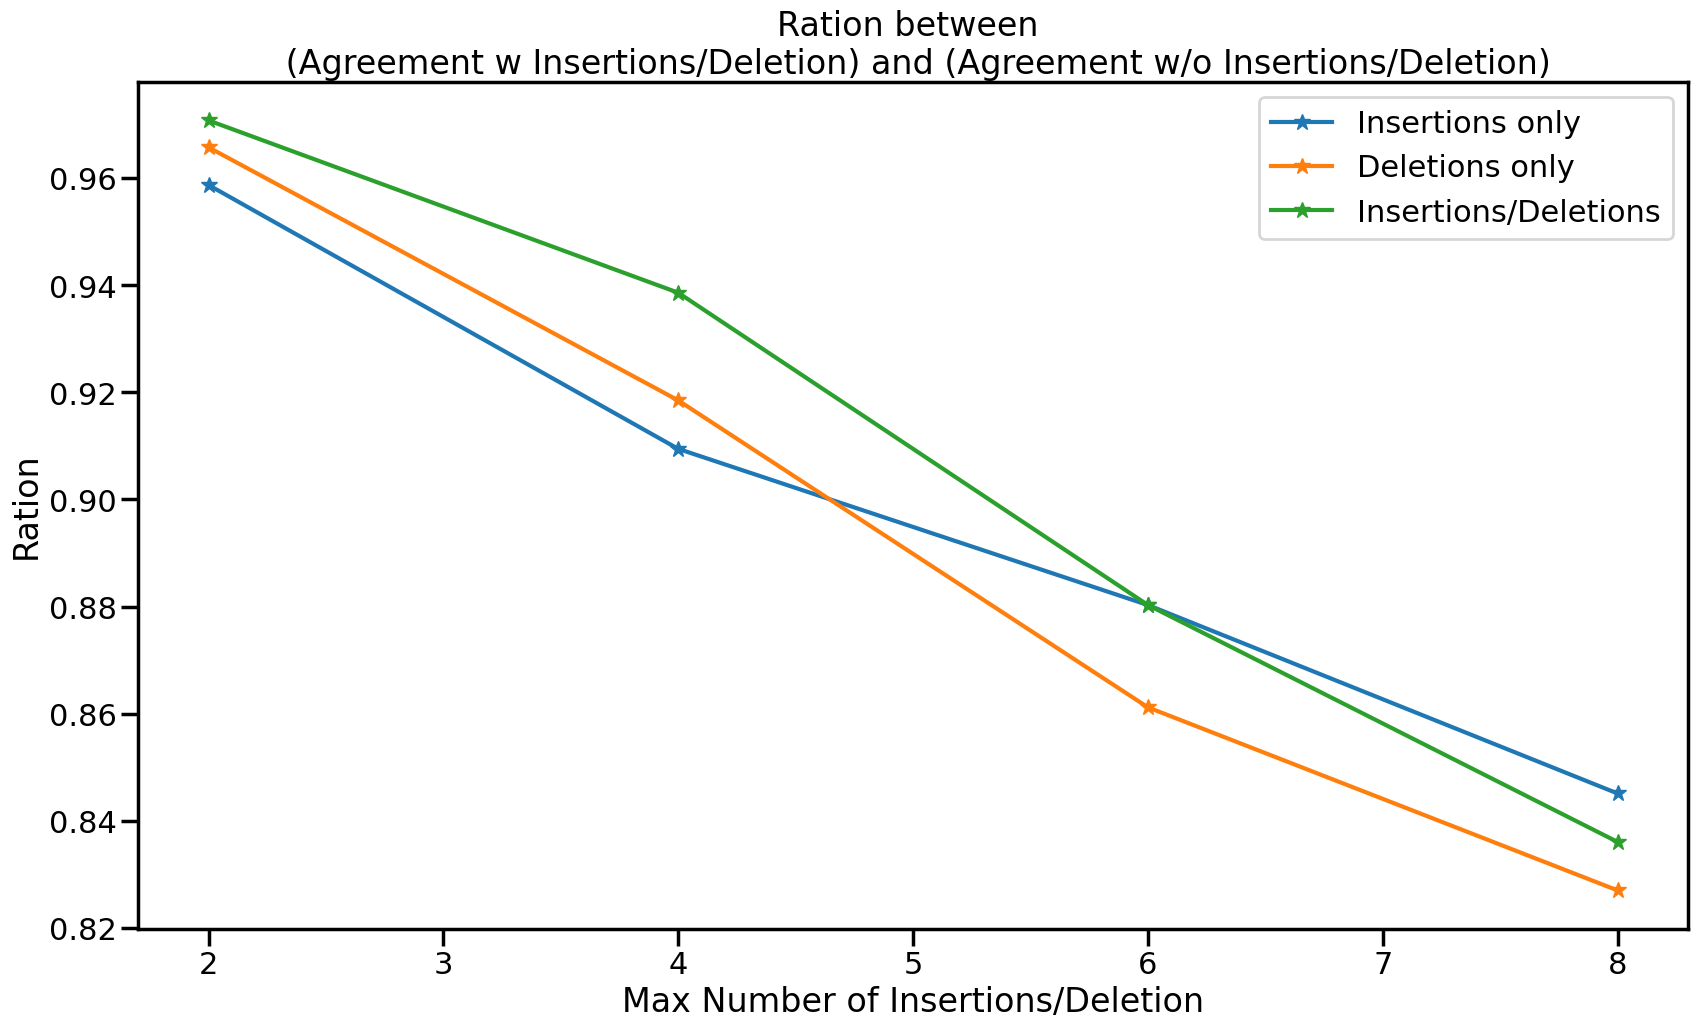

In [124]:
plt.figure()
plt.title("Ration between \n (Agreement w Insertions/Deletion) and (Agreement w/o Insertions/Deletion)")
plt.plot(max_num_insertions, ratios_insertions, "*-", label="Insertions only")
plt.plot(max_num_insertions, ratios_deletions, "*-", label="Deletions only")
plt.plot(max_num_insertions, ratios_insertions_deletions, "*-", label="Insertions/Deletions")
plt.xlabel("Max Number of Insertions/Deletion")
plt.ylabel("Ration")
plt.legend()
plt.show()

In [48]:
eval_dataset_insertion = trainer.train_dataset.tokenize_sequences(random_subset_insertion.sequence.to_list())

100%|██████████| 1000/1000 [00:00<00:00, 9268.48it/s]

AGGREMENT_wo_insertion =  0.994
AGGREMENT_insertion =  0.986
AGGREMENT_insertion/AGGREMENT_wo_insertion =  0.9919517102615694


In [104]:
a = [len(x) for x in random_subset_insertion.sequence.to_list()]
b = [len(x) for x in random_subset.sequence.to_list()]

a =  np.array(a)
b =  np.array(b)

(b - a)[252] 

-102

In [102]:
a[252]

406

In [103]:
b[252]

304

In [14]:
eval_dataset_insertion = trainer.train_dataset.tokenize_sequences(random_subset_insertion.sequence.to_list())
eval_dataset_wo_insertion = trainer.train_dataset.tokenize_sequences(random_subset.sequence.to_list())
print("Train Dataset Encoded!")

Train Dataset Encoded!


In [15]:
padded_seqs_tensor_insertion = tf.convert_to_tensor(eval_dataset_insertion, dtype=tf.uint8)
padded_seqs_tensor_wo_insertion = tf.convert_to_tensor(eval_dataset_wo_insertion, dtype=tf.uint8)

dataset_from_tensors_insertion = tf.data.Dataset.from_tensor_slices(
    {"tokenized_sequence": padded_seqs_tensor_insertion}
)
dataset_from_tensors_wo_insertion = tf.data.Dataset.from_tensor_slices(
    {"tokenized_sequence": padded_seqs_tensor_wo_insertion}
)

In [17]:
dataset_insertion = dataset_from_tensors_insertion.batch(512 * 20).prefetch(tf.data.AUTOTUNE)
dataset_wo_insertion = dataset_from_tensors_wo_insertion.batch(512 * 20).prefetch(tf.data.AUTOTUNE)

In [18]:
raw_predictions_insertion = []
raw_predictions_wo_insertion = []

for i in tqdm(dataset_insertion):
    pred = trainer.model.predict(i, verbose=False, batch_size=64)
    for k in ["v", "d", "j"]:
        pred[k + "_segment"] = pred[k + "_segment"].astype(np.float16)
    raw_predictions_insertion.append(pred)

for i in tqdm(dataset_wo_insertion):
    pred = trainer.model.predict(i, verbose=False, batch_size=64)
    for k in ["v", "d", "j"]:
        pred[k + "_segment"] = pred[k + "_segment"].astype(np.float16)
    raw_predictions_wo_insertion.append(pred)

  0%|          | 0/1 [00:00<?, ?it/s]

Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module 'gast' has no attribute 'Index'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module 'gast' has no attribute 'Index'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


2023-10-31 08:48:53.156586: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:116] None of the MLIR optimization passes are enabled (registered 2)
2023-10-31 08:48:53.157296: I tensorflow/core/platform/profile_utils/cpu_utils.cc:112] CPU Frequency: 2100000000 Hz
2023-10-31 08:48:54.380161: I tensorflow/stream_executor/platform/default/dso_loader.cc:49] Successfully opened dynamic library libcublas.so.10
2023-10-31 08:48:54.550648: I tensorflow/stream_executor/platform/default/dso_loader.cc:49] Successfully opened dynamic library libcudnn.so.7
2023-10-31 08:48:56.004859: W tensorflow/stream_executor/gpu/asm_compiler.cc:63] Running ptxas --version returned 256
2023-10-31 08:48:56.238384: W tensorflow/stream_executor/gpu/redzone_allocator.cc:314] Internal: ptxas exited with non-zero error code 256, output: 
Relying on driver to perform ptx compilation. 
Modify $PATH to customize ptxas location.
This message will be only logged once.
100%|██████████| 1/1 [00:00<00:00,  2.46it/s]


In [ ]:
raw_predictions_insertion[0].keys()

dict_keys(['v_segment', 'd_segment', 'j_segment', 'v_allele', 'd_allele', 'j_allele'])

In [19]:
v_allele_aligner_insertion = [x["v_allele"] for x in raw_predictions_insertion]
v_allele_aligner_insertion = np.concatenate(v_allele_aligner_insertion)

v_allele_aligner_wo_insertion = [x["v_allele"] for x in raw_predictions_wo_insertion]
v_allele_aligner_wo_insertion = np.concatenate(v_allele_aligner_wo_insertion)

In [28]:
V_insertion = extract_prediction_alleles_dynamic_sum(v_allele_aligner_insertion, percentage=0.9)
V_wo_insertion = extract_prediction_alleles_dynamic_sum(v_allele_aligner_wo_insertion, percentage=0.9)

hits_insertion = [len(set(i.split(",")) & set(j)) > 0 for i, j in zip(random_subset_insertion.v_call, V_insertion)]
hits_wo_insertion = [len(set(i.split(",")) & set(j)) > 0 for i, j in zip(random_subset_insertion.v_call, V_wo_insertion)]

AGGREMENT_insertion = sum(hits_insertion) / len(hits_insertion)
AGGREMENT_wo_insertion = sum(hits_wo_insertion) / len(hits_wo_insertion)

100%|██████████| 1000/1000 [00:00<00:00, 12779.68it/s]


In [45]:
insertion_wrong_indices = [i for i, (wo, ins) in enumerate(zip(hits_wo_insertion, hits_insertion)) if wo and not ins]
insertion_wrong_indices

[189, 208, 267, 315, 451, 469, 613, 624, 653, 700, 925]

In [32]:
AGGREMENT_wo_insertion

0.994

In [33]:
hits_wo_insertion

[True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 False,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True

In [31]:
AGGREMENT_insertion


0.986

In [34]:
v_segment_insertion = [x["v_segment"] for x in raw_predictions_insertion]
v_segment_insertion = np.concatenate(v_segment_insertion)

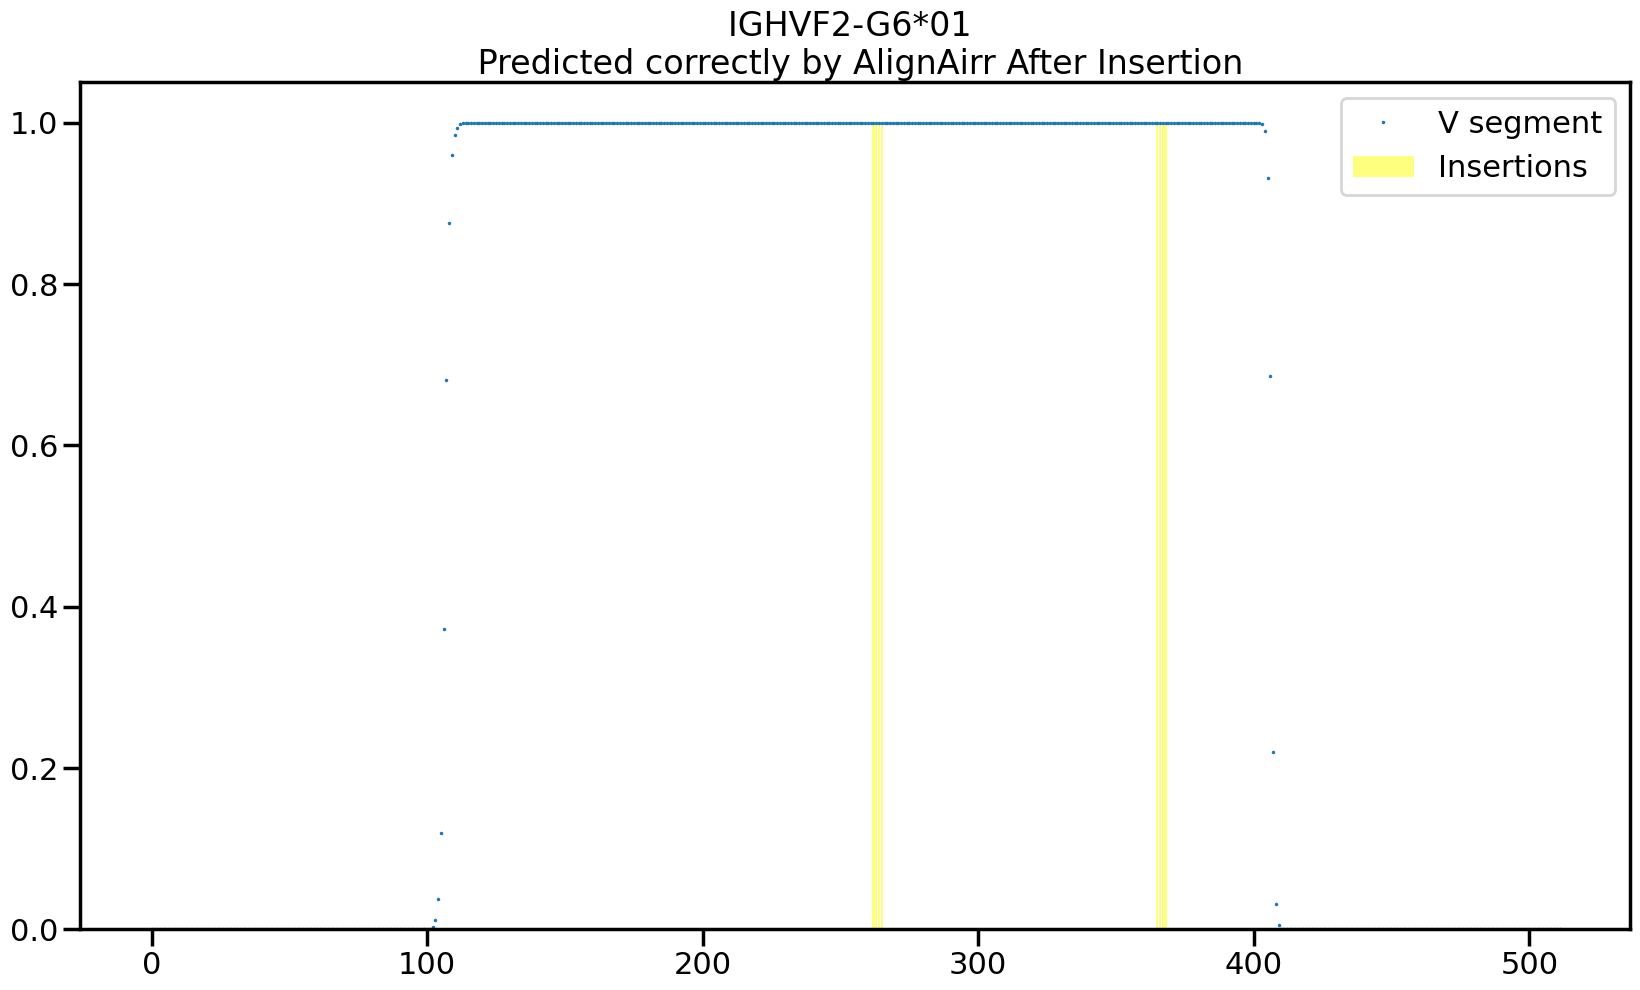

In [43]:
fig, ax = plt.subplots()
plt.title(f"{random_subset_insertion.iloc[0, :]['v_call']} \n Predicted correctly by AlignAirr After Insertion")
v_segment_plot, = plt.plot(v_segment_insertion[0], '.', markersize=3, label="V segment")
insertion_plots = []

for start, end in random_subset_insertion.iloc[0, :]["insertions_positions"]:
    ax.bar(range(start, end), [1] * (end - start), color='yellow', alpha=0.5)
    insertion_plots.append(ax.bar(0, 0, color='yellow', alpha=0.5))  # Add empty bars to create a legend entry for "Insertions"

plt.legend(handles=[v_segment_plot] + insertion_plots, labels=["V segment", "Insertions"])
plt.show()


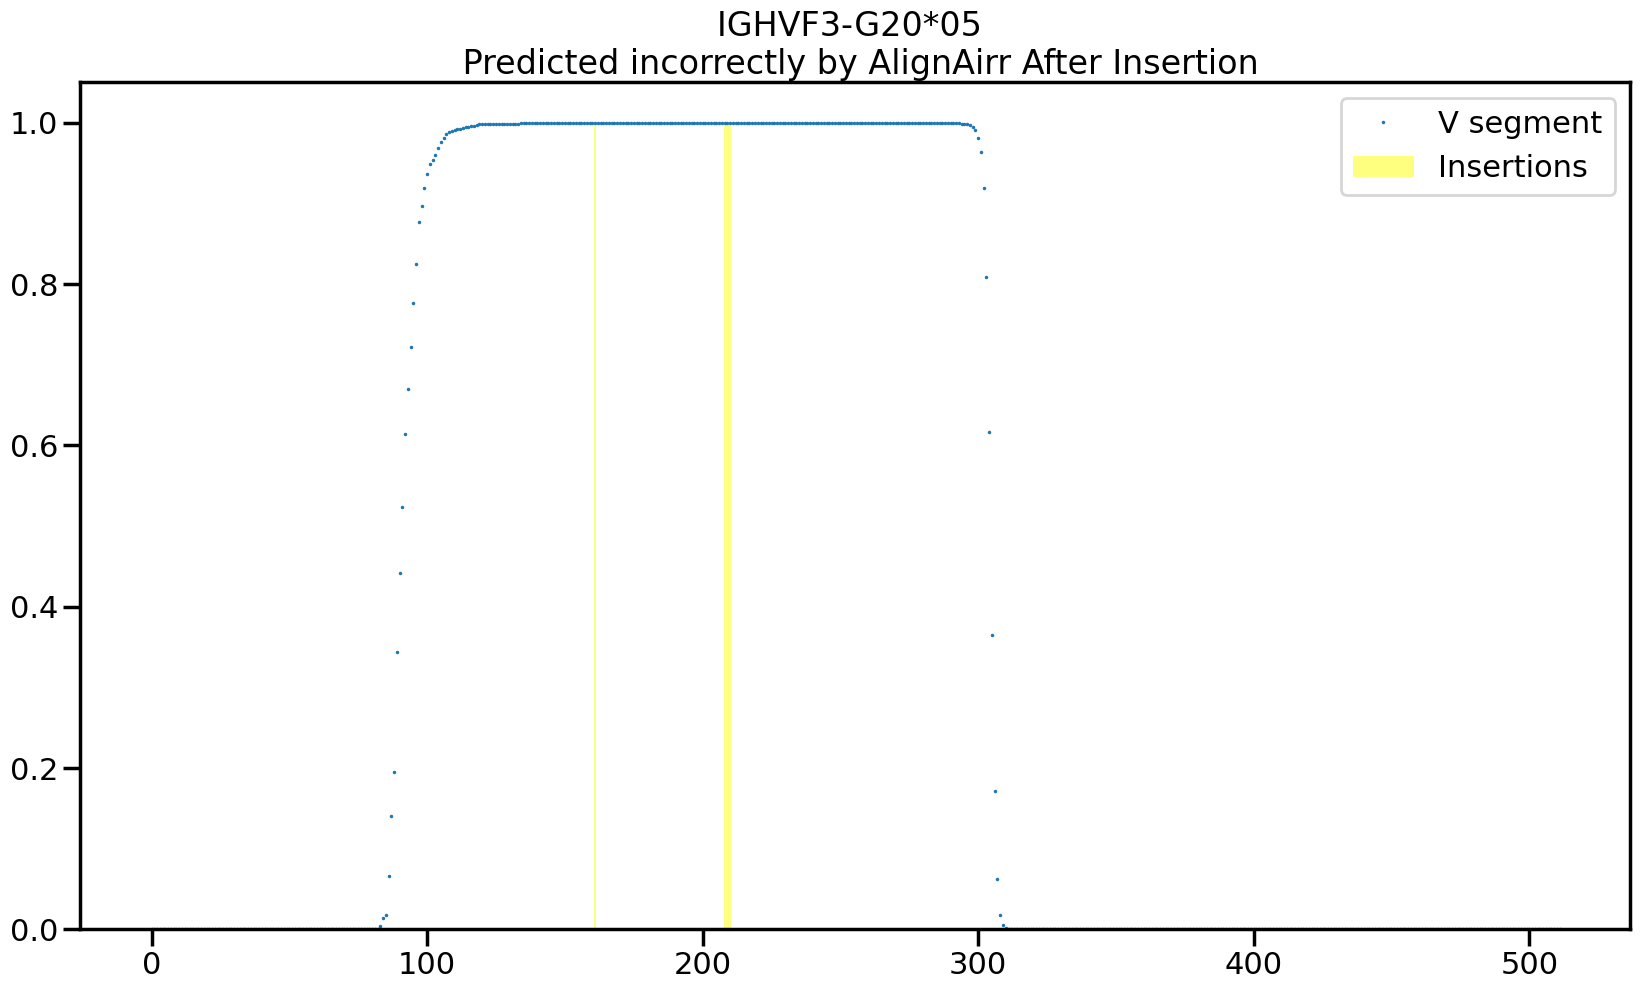

In [46]:
idx = 189
fig, ax = plt.subplots()
plt.title(f"{random_subset_insertion.iloc[idx, :]['v_call']} \n Predicted incorrectly by AlignAirr After Insertion")
v_segment_plot, = plt.plot(v_segment_insertion[idx], '.', markersize=3, label="V segment")
insertion_plots = []

for start, end in random_subset_insertion.iloc[idx, :]["insertions_positions"]:
    ax.bar(range(start, end), [1] * (end - start), color='yellow', alpha=0.5)
    insertion_plots.append(ax.bar(0, 0, color='yellow', alpha=0.5))  # Add empty bars to create a legend entry for "Insertions"

plt.legend(handles=[v_segment_plot] + insertion_plots, labels=["V segment", "Insertions"])
plt.show()

In [78]:
random_subset_insertion.v_sequence_end

867861     414
1470272    206
1582930    412
1100812    390
921510     324
          ... 
1892752    395
1075823    393
1910735    396
2349374    402
2290486     38
Name: v_sequence_end, Length: 1000, dtype: int64

[(139, 141), (291, 292)]

In [125]:
a = 2737637 
b = 21698
print(a/(a+b))
print(b/(a+b))

0.9921365111521435
0.007863488847856459
